In [ ]:
# sudo yum update -y
# sudo yum install -y docker
# sudo service docker start
# sudo usermod -aG docker ec2-user


In [2]:
!pip -q install matplotlib


# ✅  Cell 1 — Index ONCE into Qdrant (run once)

In [8]:
!pip -q install --upgrade qdrant-client matplotlib pillow tqdm numpy torch torchvision transformers

import os, glob, re, hashlib
import numpy as np
from tqdm import tqdm
from PIL import Image

from qdrant_client import QdrantClient
from qdrant_client.http import models as qm

import torch
from transformers import CLIPProcessor, CLIPModel

# --------------------------
# CONFIG
# --------------------------
IMG_DIR = "/home/ec2-user/rag-project/extracted_images_cropped_nova_resume"
COLLECTION = "radio_images"
DONE_FLAG = "/home/ec2-user/rag-project/.qdrant_index_done.flag"

# --------------------------
# QDRANT
# --------------------------
qdrant = QdrantClient(host="localhost", port=6333)

# --------------------------
# EMBEDDING MODEL (CLIP, local)
# --------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model_name = "openai/clip-vit-base-patch32"

processor = CLIPProcessor.from_pretrained(clip_model_name)
model = CLIPModel.from_pretrained(clip_model_name).to(device)
model.eval()

def embed_image(path: str) -> np.ndarray:
    img = Image.open(path).convert("RGB")
    inputs = processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        feats = model.get_image_features(**inputs)
    vec = feats[0].cpu().numpy().astype(np.float32)
    vec = vec / (np.linalg.norm(vec) + 1e-12)  # cosine-ready
    return vec

def parse_meta(filename: str):
    m = re.search(r"(.*)_p(\d{4})_img(\d{2})", filename)
    if not m:
        return {"doc": None, "page": None, "img": None}
    return {"doc": m.group(1), "page": int(m.group(2)), "img": int(m.group(3))}

def file_sha1(path: str) -> str:
    h = hashlib.sha1()
    with open(path, "rb") as f:
        while True:
            b = f.read(1024 * 1024)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

# --------------------------
# INDEX ONLY IF NOT DONE
# --------------------------

# --------------------------
# FORCE RESET (wipe Qdrant + allow re-index)
# --------------------------
if qdrant.collection_exists(COLLECTION):
    print(f"🧹 Deleting collection '{COLLECTION}'...")
    qdrant.delete_collection(COLLECTION)

if os.path.exists(DONE_FLAG):
    print(f"🧹 Removing DONE flag '{DONE_FLAG}'...")
    os.remove(DONE_FLAG)

print("✅ Reset complete. Next run will re-index from scratch.")


if os.path.exists(DONE_FLAG):
    print("✅ Index already exists (DONE flag found). Skipping indexing.")
else:
    image_paths = sorted(glob.glob(os.path.join(IMG_DIR, "*.png")))
    if not image_paths:
        raise RuntimeError(f"No PNG images found in: {IMG_DIR}")

    dim = len(embed_image(image_paths[0]))
    print("✅ Embedding dimension =", dim)
    print("✅ Images found =", len(image_paths))

    # recreate collection
    try:
        if qdrant.collection_exists(COLLECTION):
            qdrant.delete_collection(COLLECTION)
    except Exception:
        pass

    qdrant.create_collection(
        collection_name=COLLECTION,
        vectors_config=qm.VectorParams(size=dim, distance=qm.Distance.COSINE),
    )

    points = []
    for idx, path in enumerate(tqdm(image_paths, desc="Indexing images into Qdrant")):
        filename = os.path.basename(path)
        meta = parse_meta(filename)
        vec = embed_image(path)
        sha = file_sha1(path)

        points.append(
            qm.PointStruct(
                id=idx,
                vector=vec.tolist(),
                payload={
                    "path": path,
                    "filename": filename,
                    "sha1": sha,
                    **meta
                },
            )
        )

    # batch insert
    BATCH = 64
    for start in range(0, len(points), BATCH):
        qdrant.upsert(collection_name=COLLECTION, points=points[start:start + BATCH])

    # write done flag
    with open(DONE_FLAG, "w") as f:
        f.write("done")

    print(f"✅ Indexed {len(points)} images into Qdrant collection '{COLLECTION}'")
    print("✅ DONE flag created:", DONE_FLAG)


🧹 Deleting collection 'radio_images'...
🧹 Removing DONE flag '/home/ec2-user/rag-project/.qdrant_index_done.flag'...
✅ Reset complete. Next run will re-index from scratch.
✅ Embedding dimension = 512
✅ Images found = 427


Indexing images into Qdrant: 100%|██████████| 427/427 [01:26<00:00,  4.95it/s]


✅ Indexed 427 images into Qdrant collection 'radio_images'
✅ DONE flag created: /home/ec2-user/rag-project/.qdrant_index_done.flag


# ✅ Cell 2 — Query + retrieve similar images (FAST)


🔎 Top matches:
score=1.0000 | Radio Luxembourg 1979_p0043_img02.png | page=43
score=0.8156 | Radio Luxembourg Record Stars No1_p0022_img02.png | page=22
score=0.7960 | Radio Luxembourg Record Stars Book No5_p0044_img02.png | page=44
score=0.7936 | Radio Luxembourg Record Stars Book No5_p0041_img01.png | page=41
score=0.7911 | Radio Luxembourg Record Stars Book No5_p0017_img01.png | page=17
score=0.7909 | Radio Luxembourg Record Stars Book No5_p0097_img01.png | page=97
score=0.7893 | Radio Luxembourg Record Stars No1_p0063_img01.png | page=63
score=0.7889 | Radio Luxembourg, The station of the stars_p0129_img01.png | page=129
score=0.7857 | Radio Luxembourg 1979_p0035_img01-Copy1.png | page=35
score=0.7805 | Radio Luxembourg Record Stars No1_p0062_img01.png | page=62


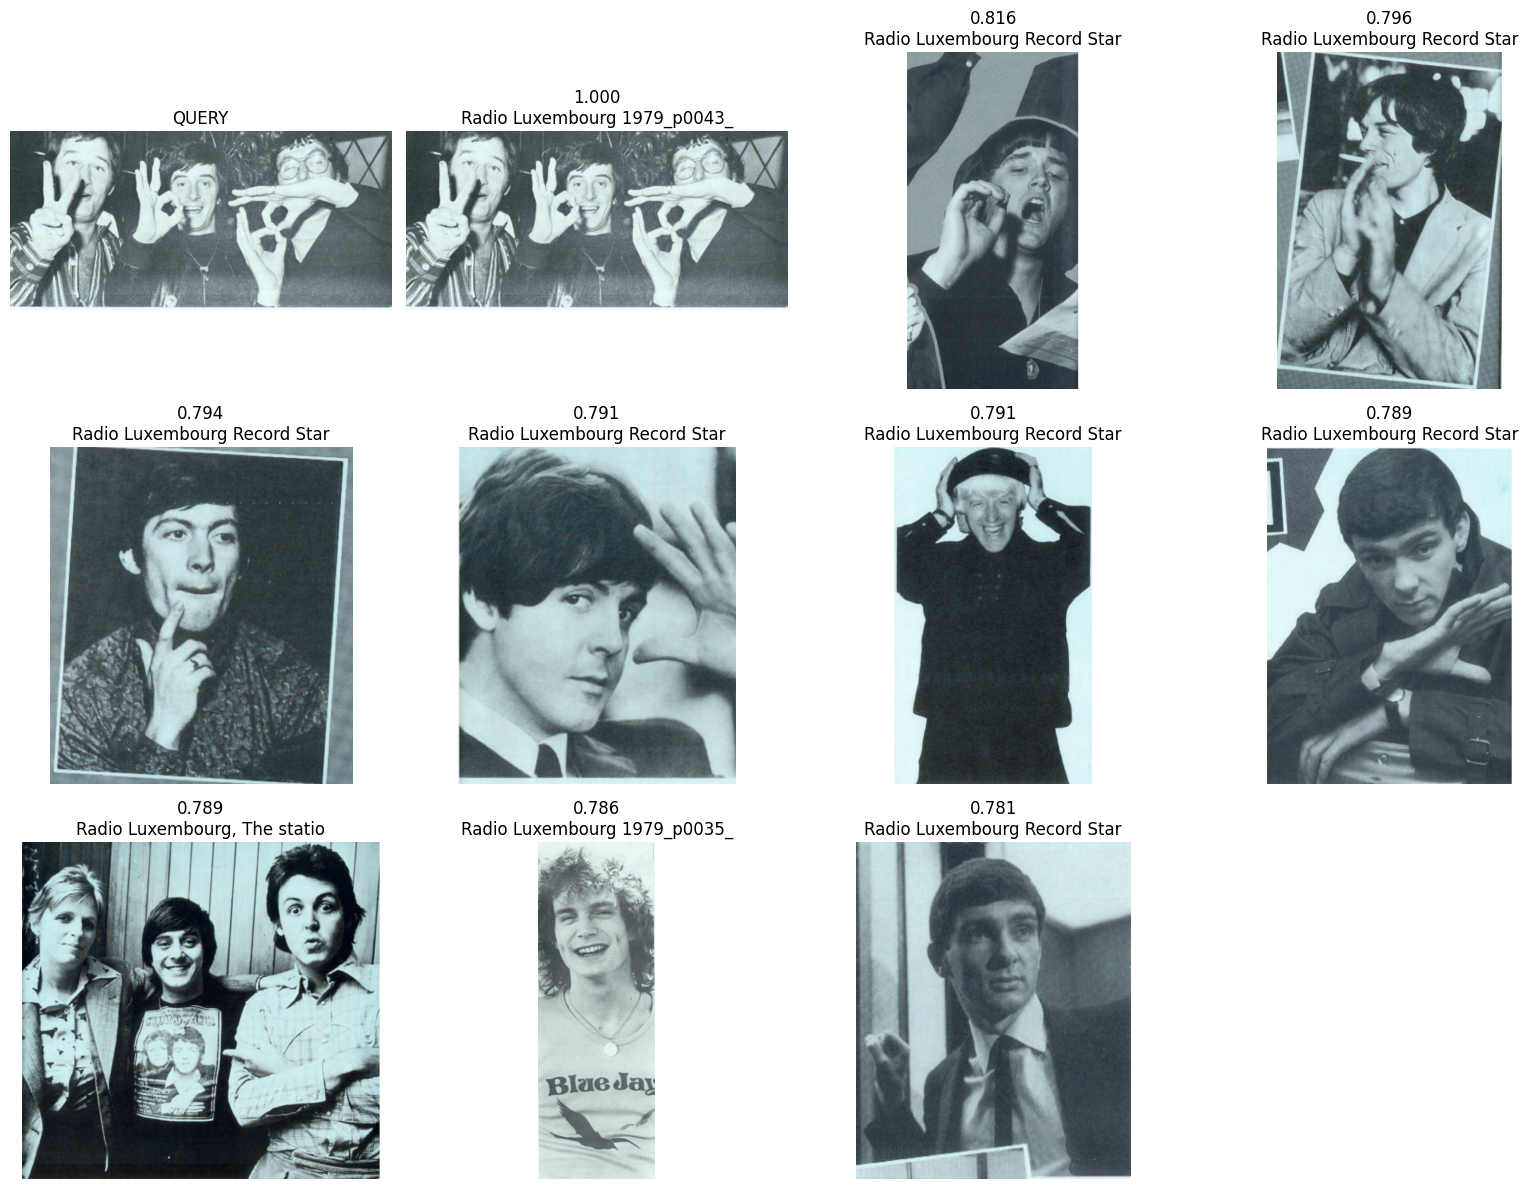

In [7]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

from qdrant_client import QdrantClient
import torch
from transformers import CLIPProcessor, CLIPModel

# --------------------------
# CONFIG
# --------------------------
COLLECTION = "radio_images"
TOP_K = 10

# ✅ Change this to user uploaded image path
QUERY_IMAGE = "/home/ec2-user/rag-project/extracted_images_cropped_nova_resume/" + os.listdir(
    "/home/ec2-user/rag-project/extracted_images_cropped_nova_resume"
)[0]

# --------------------------
# QDRANT
# --------------------------
qdrant = QdrantClient(host="localhost", port=6333)

# --------------------------
# EMBEDDING MODEL (same CLIP)
# --------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model_name = "openai/clip-vit-base-patch32"

processor = CLIPProcessor.from_pretrained(clip_model_name)
model = CLIPModel.from_pretrained(clip_model_name).to(device)
model.eval()

def embed_image(path: str) -> np.ndarray:
    img = Image.open(path).convert("RGB")
    inputs = processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        feats = model.get_image_features(**inputs)
    vec = feats[0].cpu().numpy().astype(np.float32)
    vec = vec / (np.linalg.norm(vec) + 1e-12)
    return vec

# --------------------------
# QUERY QDRANT (works across versions)
# --------------------------
qvec = embed_image(QUERY_IMAGE).tolist()

if hasattr(qdrant, "query_points"):
    res = qdrant.query_points(
        collection_name=COLLECTION,
        query=qvec,
        limit=TOP_K,
        with_payload=True
    )
    hits = res.points
else:
    hits = qdrant.search(
        collection_name=COLLECTION,
        query_vector=qvec,
        limit=TOP_K,
        with_payload=True
    )

# --------------------------
# DEDUP BY sha1 (avoid same duplicates)
# --------------------------
seen = set()
filtered_hits = []
for h in hits:
    sha = (h.payload or {}).get("sha1")
    if sha and sha in seen:
        continue
    if sha:
        seen.add(sha)
    filtered_hits.append(h)

# --------------------------
# PRINT RESULTS
# --------------------------
print("\n🔎 Top matches:")
for h in filtered_hits[:TOP_K]:
    p = h.payload or {}
    print(f"score={h.score:.4f} | {p.get('filename')} | page={p.get('page')}")

# --------------------------
# DISPLAY
# --------------------------
def show_images(query_path, hit_list, cols=4):
    query_img = Image.open(query_path).convert("RGB")
    n = len(hit_list)
    rows = int(np.ceil((n + 1) / cols))

    plt.figure(figsize=(4*cols, 4*rows))

    plt.subplot(rows, cols, 1)
    plt.imshow(query_img)
    plt.axis("off")
    plt.title("QUERY")

    for i, h in enumerate(hit_list, start=2):
        payload = h.payload or {}
        img_path = payload["path"]
        img = Image.open(img_path).convert("RGB")
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{h.score:.3f}\n{payload.get('filename','')[:28]}")

    plt.tight_layout()
    plt.show()

show_images(QUERY_IMAGE, filtered_hits[:TOP_K], cols=4)
